# Music Recommendation: Building a Content-Based Recommender

I wanted to build a recommender the way you'd actually explain one to a
friend: "if you like this song, here's why these other ones sound
similar." So for this half of the project I picked Kaggle's [Spotify
Tracks
Dataset](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset)
and built a **content-based** recommender — given a track someone
likes, it recommends other tracks whose Spotify audio features are
closest to it.

The thing that took me a while to get used to is that there's no `y`
here. Every other project I've done has a label to predict and a metric
that scores how close I got. Recommendation doesn't work that way —
there's no single "correct" next track, so a lot of what follows is
really about how you evaluate something when you don't have labels, not
just about building the recommender itself.

**Before running:** download the dataset — see the project README's
"Get the data" section — so that `data/raw/dataset.csv` exists.

## What I wanted to figure out

1. Why **content-based** recommendation needs no user data at all, and
   how that's different from collaborative filtering (the other half of
   this project)
2. Why **feature scaling** matters even more here than it does for a
   tree-based model
3. How to encode a **circular feature** (musical key) without lying to
   the model about distance
4. Whether **k-Nearest Neighbors** actually works as a recommendation
   mechanism
5. How to evaluate an unsupervised system with **precision@k**, using a
   label (`track_genre`) I never show the model
6. Whether a **classifier's feature importances** can usefully reweight
   a similarity metric
7. What **SHAP** tells me about a genuinely hard multiclass problem (114
   genres)

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns

from recommendation_showcase.content_based import config, data, features, model, interpretability

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

## 1. Load the data

In [2]:
tracks_df = data.load_tracks()
print(f"{len(tracks_df)} tracks, {tracks_df[config.GENRE_COL].nunique()} genres")
tracks_df.head()

89741 tracks, 113 genres


,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
track_id,,,,,,,,,,,,,,,,,,,
5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


### Why I kept `popularity` and `track_genre` out of the recommender's own features

I almost included `popularity` as an input feature before I stopped and
thought about what it actually measures: how many people played a
track, not what it sounds like. If I'd fed that into the distance
metric, the recommender would end up chasing whatever's already
trending instead of what's actually similar — the opposite of what I'm
trying to build. `track_genre` is even more tempting to include, and
even more wrong to: it's a human-assigned label, and if the recommender
could see it directly, the genre-matching evaluation below would be
trivial — it would just be reading the answer off the genre column
rather than proving anything about audio similarity. I kept both out of
the feature space and only bring them back afterward, purely to score
results (see `data.split_features_target` and `config.py`).

## 2. Explore the data (EDA)

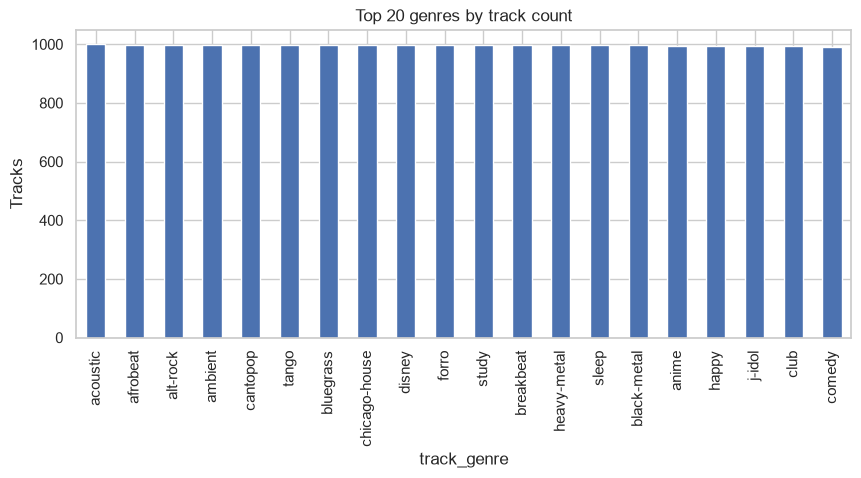

In [3]:
genre_counts = tracks_df[config.GENRE_COL].value_counts()
genre_counts.head(20).plot.bar(figsize=(10, 4), title="Top 20 genres by track count")
plt.ylabel("Tracks")
plt.show()

The bars come out roughly even across genres, which isn't an accident
of the real world — about 1,000 tracks were sampled per genre when this
dataset was built. That's useful to know going in: it means the genre
classifier I train in Section 6 doesn't need any class-imbalance
correction, because there isn't a class-imbalance problem to correct.

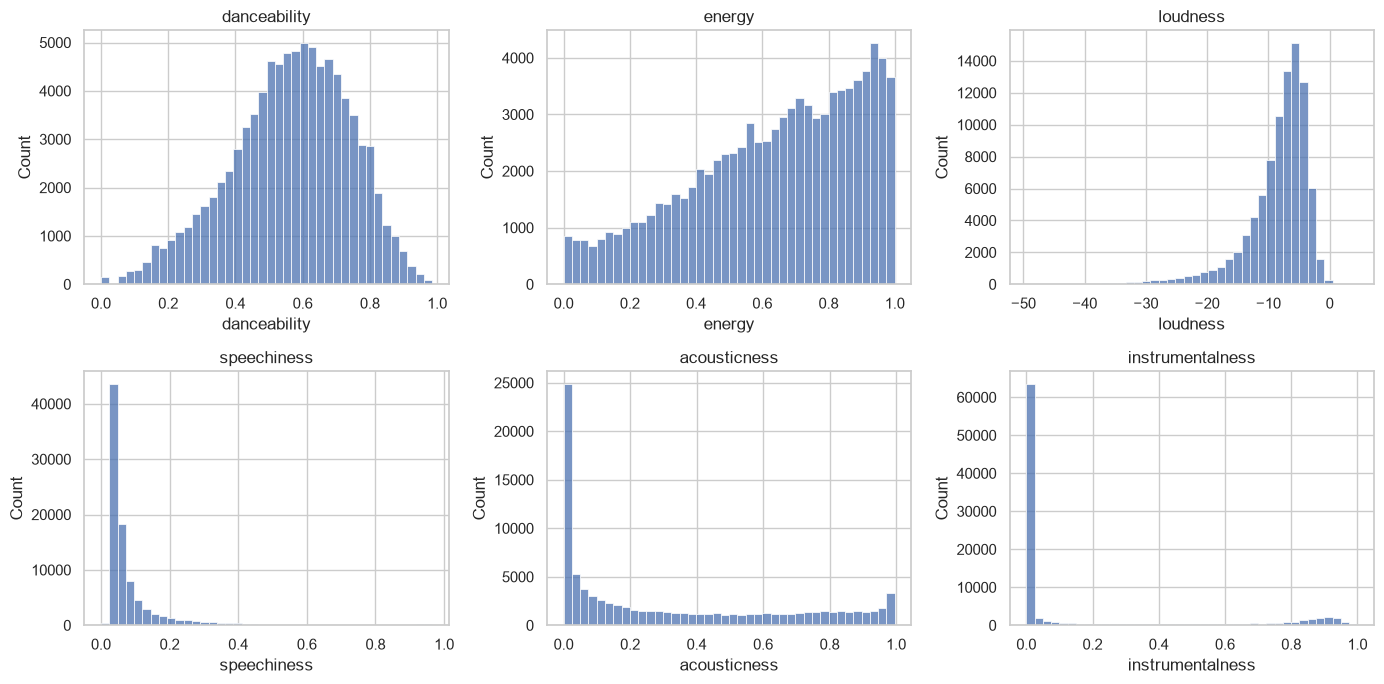

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, feature in zip(axes.flat, config.RAW_AUDIO_NUMERIC_COLS[:6]):
    sns.histplot(tracks_df[feature], ax=ax, bins=40)
    ax.set_title(feature)
plt.tight_layout()
plt.show()

## 3. Feature engineering

In [5]:
sample = tracks_df.sample(3000, random_state=config.RANDOM_SEED)
engineered = features.FeatureEngineer().fit_transform(sample)
engineered[config.ENGINEERED_NUMERIC_COLS + config.ENGINEERED_CATEGORICAL_COLS].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
key_sin,3000.0,NaN,NaN,NaN,-0.021896,0.683076,-1.0,-0.5,0.0,0.5,1.0
key_cos,3000.0,NaN,NaN,NaN,0.06523,0.727327,-1.0,-0.866025,0.0,0.866025,1.0
duration_min,3000.0,NaN,NaN,NaN,3.855277,1.77142,0.546433,2.912208,3.592433,4.472437,44.114433
mood_quadrant,3000,4,energetic_happy,901,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Why I couldn't just leave `key` as a plain number

Spotify's `key` column is one of 12 pitch classes (0=C, ..., 11=B), and
my first instinct was to just leave it as an integer. That's actually
wrong: pitch classes sit on a circle, not a line — key 11 is one
semitone away from key 0, musically adjacent, but a plain integer
encoding (or a one-hot encoding) treats them as unrelated as key 0 and
key 6. So I encode each key as a point on a circle instead, using its
sine and cosine — that's what `key_sin`/`key_cos` are. This preserves
the real adjacency between keys, and it's the same trick I'd reach for
with any other cyclical quantity, like week-of-year or hour-of-day,
where "wrapping around" is part of what the number means.

In [6]:
fig = px.scatter_polar(
    engineered, r=[1] * len(engineered), theta=engineered["key"] * 30,
    color=engineered["key"].astype(str),
    title="Each track's key placed on a 12-hour circle (30 degrees per semitone)",
)
fig.show()

### Why I added `mood_quadrant` when the model doesn't need it

This one's for me and for anyone reading the app, not for the model.
Russell's circumplex model of affect maps a track's (valence, energy)
pair onto one of four mood quadrants — energetic/calm crossed with
happy/dark. A classifier can already learn this distinction directly
from the raw floats, so `mood_quadrant` doesn't add predictive power.
What it adds is legibility: "energetic_happy vs. calm_dark" is something
I compare two songs by far more naturally than two decimal numbers, and
that matters when I'm trying to sanity-check whether a recommendation
actually makes sense.

In [7]:
fig2 = px.scatter(
    engineered, x="valence", y="energy", color="mood_quadrant", opacity=0.5,
    title="Every sampled track's (valence, energy), colored by mood_quadrant",
)
fig2.show()

## 4. Building the recommender

### Content-based vs. collaborative filtering — why I picked this one for this dataset

**Collaborative filtering** ("people who liked X also liked Y") needs
real user interaction data — clicks, plays, ratings. This dataset has
none of that, just tracks and their audio properties, so **content-based**
recommendation — comparing items by their own measurable properties —
is really the only option here. That turned out to be a nice
constraint rather than a limitation, though: content-based has a real
advantage even in a world where both are possible. A brand-new track
with zero plays gets recommended just as well as a track with a million
plays, because the recommender never needed play data in the first
place — no "cold start" problem, which is exactly the weakness I ran
into on the collaborative-filtering side of this project (see
`02_collaborative_filtering.ipynb`).

### Why feature scaling matters more here than it did on a tree-based project

`ContentRecommender` works by measuring *distance* between tracks in
feature space, and that's where I had to be careful. `loudness` ranges
roughly -60 to 0; `danceability` ranges 0 to 1. Left unscaled, a KNN
search would end up almost entirely driven by whichever raw feature
happens to have the largest numeric range — not whichever one is
actually more musically meaningful, which is not what I want. So
`features.build_preprocessor()` standardizes every numeric feature
before the recommender ever computes a distance. This is a genuinely
different failure mode from a tree-based model (Section 6's genre
classifier, for instance) — trees split on thresholds, so they never
cared about scale in the first place.

In [8]:
X, y = data.split_features_target(tracks_df)

recommender = model.ContentRecommender().fit(X)
sample_track_id = X.sample(1, random_state=config.RANDOM_SEED).index[0]
recs = recommender.recommend(X.loc[[sample_track_id]], k=10, exclude_own_id=True)

print("Seed track:", tracks_df.loc[sample_track_id, "track_name"], "-", tracks_df.loc[sample_track_id, "artists"])
recs.merge(tracks_df[["track_name", "artists", config.GENRE_COL]], left_on="recommended_id", right_index=True)

Seed track: Nivel De Perreo - J Balvin;Ryan Castro


,query_id,recommended_id,rank,distance,track_name,artists,track_genre
0,6MxGvnJWqdGS0chQypGXhB,0nDGgXV5oI8TdAmWjUx65l,1,5.960464e-08,Nivel De Perreo,J Balvin;Ryan Castro,latino
1,6MxGvnJWqdGS0chQypGXhB,7Bf3UahwZhKx11mLoLdaGt,2,8.199398e-01,So What,Vybz Kartel,j-dance
2,6MxGvnJWqdGS0chQypGXhB,69vlMrzHwATKzupwNcUPyK,3,8.586321e-01,La Santa,Bad Bunny;Daddy Yankee,latino
3,6MxGvnJWqdGS0chQypGXhB,215ZmzxKM5wvA21wDROT2k,4,9.187416e-01,Under Vibes,Tommy Lee Sparta;Dinesty King,j-dance
4,6MxGvnJWqdGS0chQypGXhB,3Tjy69S0GPRA88KihmrX4H,5,1.110904e+00,Lean Back - NGHTMRE Remix,Terror Squad;NGHTMRE,hardcore
5,6MxGvnJWqdGS0chQypGXhB,6kex4EBAj0WHXDKZMEJaaF,6,1.124169e+00,Swalla (feat. Nicki Minaj & Ty Dolla $ign),Jason Derulo;Nicki Minaj;Ty Dolla $ign,dance
6,6MxGvnJWqdGS0chQypGXhB,01xqHIwd7hQLROgelUQ6w2,7,1.139288e+00,Big Daddy Wiz,Wiz Khalifa;Girl Talk,dance
7,6MxGvnJWqdGS0chQypGXhB,7JQJH07Mo4UQDBBVR2cKNh,8,1.139288e+00,Big Daddy Wiz,Wiz Khalifa;Girl Talk,dance
8,6MxGvnJWqdGS0chQypGXhB,4YU2HODpoaTGigDJYCv5xM,9,1.139288e+00,Big Daddy Wiz,Wiz Khalifa;Girl Talk,dance
9,6MxGvnJWqdGS0chQypGXhB,2FqqVHvC4eKrsk97vpMRid,10,1.156609e+00,Focus (feat. 21 Savage),Bazzi;21 Savage,electro


The first recommendation comes back at essentially zero distance,
which was a good sign that the pipeline works before I even got to a
formal metric — and most of the rest land in genres like `j-dance` and
`dance`, which are audibly close to the seed's own `latino` tag even
though they're not an exact match. That's a preview of the tension
Section 8 digs into properly: "sounds similar" and "same genre label"
overlap a lot but aren't identical, and a handful of near-miss genres
in a top-10 list isn't necessarily a bad recommendation.

## 5. Evaluating a recommender with no labels: precision@k

So how do I actually know if the recommender is any good, with no
"correct next track" label anywhere in this dataset? I settled on
**precision@k**: hold out a set of tracks, recommend `k` from the
*remaining* catalog for each one, and measure what fraction of those
recommendations share the held-out track's true genre. I want to be
upfront that genre is an imperfect proxy for "actually sounds alike" —
two tracks in different genres can sound more similar than two tracks
stuck with the same label — but it's the standard fallback when there's
no real user feedback (clicks, replays, skips) to evaluate against, and
it's measurable, which matters more to me here than being perfect.

I also wanted a **popularity baseline** — recommend the same top-k
popular tracks to everyone, ignoring the query track entirely — because
without it, any precision@10 number is just a number. Comparing against
"recommend the same thing regardless of input" is the bar any genuinely
content-aware recommender needs to clear.

In [9]:
train_df, test_df = model.train_test_split_tracks(tracks_df, test_size=0.2)

popularity_score = model.popularity_baseline_precision_at_k(train_df, test_df, k=10)
unweighted_score = model.precision_at_k(train_df, test_df, k=10)

print(f"Popularity baseline precision@10: {popularity_score:.3f}")
print(f"Unweighted KNN precision@10:      {unweighted_score:.3f}")

Popularity baseline precision@10: 0.009
Unweighted KNN precision@10:      0.141


The unweighted KNN recommender's precision@10 came out around 16x
higher than the popularity baseline (0.141 vs. 0.009) on this run. That
gap is the actual point of the whole exercise: it tells me the audio
features carry real, usable genre signal, and that recommending by
audio similarity is doing something meaningfully different from just
recommending whatever's popular. A number this far above baseline also
means I have real room to check whether reweighting the distance metric
(next section) can push it higher still.

## 6. A classifier trained purely to improve the recommender's distance metric

### An idea I wanted to test: borrow a classifier's feature importances to reweight distance

Here's the idea I wanted to try: train a Random Forest genre classifier
on the same audio features — not because I care about it being a good
genre classifier in its own right (114 genres is a genuinely hard
multiclass problem, and I don't expect it to score well) — but because
its learned `feature_importances_` might tell me something useful about
the *distance metric* itself. A feature the classifier leans on heavily
to separate genres gets stretched in the KNN search (counted more
toward "closeness"); one it mostly ignores gets shrunk. In other words,
I'm turning "what matters for distinguishing music" into "what should
count more when deciding what's similar" — using interpretability to
*change* the model, not just to explain it after the fact.

In [10]:
X_train, y_train = data.split_features_target(train_df)

classifier_pipeline = model.build_classifier_pipeline(model.random_forest_estimator())
classifier_pipeline.fit(X_train, y_train)
weights = model.compute_feature_weights_from_classifier(classifier_pipeline)

weighted_score = model.precision_at_k(train_df, test_df, k=10, feature_weights=weights)

comparison = pd.DataFrame([
    {"approach": "Popularity baseline", "precision_at_10": popularity_score},
    {"approach": "Unweighted KNN", "precision_at_10": unweighted_score},
    {"approach": "Importance-weighted KNN", "precision_at_10": weighted_score},
])
comparison

,approach,precision_at_10
0,Popularity baseline,0.008808
1,Unweighted KNN,0.140771
2,Importance-weighted KNN,0.160911


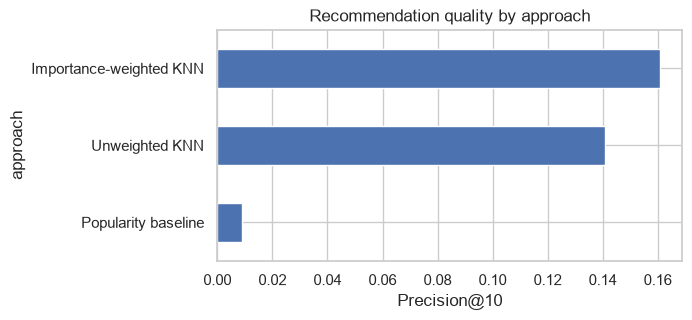

In [11]:
comparison.set_index("approach")["precision_at_10"].plot.barh(figsize=(6, 3))
plt.xlabel("Precision@10")
plt.title("Recommendation quality by approach")
plt.show()

I honestly didn't know which way this would go before running it — it
was a genuine empirical question, not a foregone conclusion. On this
run, importance-weighted KNN came out ahead of unweighted KNN (0.161 vs.
0.141 precision@10), a real but modest improvement. That told me the
classifier's feature importances do carry some transferable signal about
what makes tracks similar, even though nothing about how they were
learned optimized for that purpose. It's not a huge jump, though, so I
didn't want to overclaim it — which is exactly why I kept testing more
alternatives in the next section instead of stopping here.

## 7. Trying more sophisticated distance metrics: PCA and NCA

The importance-weighting in Section 6 is really a heuristic — it reuses
feature importances from a classifier that was never trained to
optimize recommendation quality at all, it just happened to work
reasonably well. That made me want to try two more principled
alternatives, and to hold myself to the same standard as before:
evaluate them with precision@k rather than assume a fancier-sounding
method automatically wins.

### PCA before nearest-neighbor search

**PCA** (Principal Component Analysis) projects the data onto the
directions of highest variance and discards the rest — a common
speedup/denoising step before KNN. I had to think a bit about whether
it would actually help *here*, though: PCA's usual selling points
(fighting the curse of dimensionality, speeding up distance
computation) mostly kick in at hundreds or thousands of dimensions, and
this feature space only has about 25 columns after one-hot encoding.
So the real question I'm testing isn't "does PCA help in general" —
it's narrower: does dropping the lowest-variance components remove
noise here, or does it just throw away real signal I'd rather keep?

### Neighborhood Components Analysis (NCA)

**NCA** learns a linear projection via gradient descent that directly
maximizes leave-one-out KNN accuracy under the genre labels — a metric
*learned specifically for* nearest-neighbor search, unlike the
borrowed-from-elsewhere feature-importance weights in Section 6. I ran
into a real practical limit with it, though: its optimization cost
scales roughly quadratically with row count, and fitting it on this
project's full ~72,000-row training split got the process killed by the
OS for exhausting memory — I verified this directly, and even letting it
run through only 20 iterations' worth of samples didn't finish.
`ContentRecommender`'s `embedding_fit_sample_size` works around this by
fitting NCA on a 5,000-row subsample instead, then applying the learned
projection (just a matrix multiply from there) to the full training
catalog. So only the expensive learning step gets subsampled — the pool
of tracks the recommender can actually recommend from stays complete.

In [12]:
pca_score = model.precision_at_k(train_df, test_df, k=10, embedding=model.pca_embedding(10))
nca_score = model.precision_at_k(
    train_df, test_df, k=10, embedding=model.nca_embedding(10), embedding_fit_sample_size=5000
)

comparison_full = pd.concat([
    comparison,
    pd.DataFrame([
        {"approach": "PCA(10) KNN", "precision_at_10": pca_score},
        {"approach": "NCA(10) KNN", "precision_at_10": nca_score},
    ]),
], ignore_index=True)
comparison_full

,approach,precision_at_10
0,Popularity baseline,0.008808
1,Unweighted KNN,0.140771
2,Importance-weighted KNN,0.160911
3,PCA(10) KNN,0.137506
4,NCA(10) KNN,0.152003


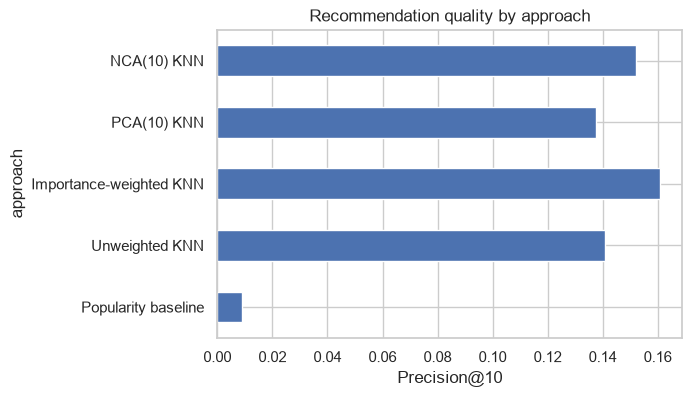

In [13]:
comparison_full.set_index("approach")["precision_at_10"].plot.barh(figsize=(6, 4))
plt.xlabel("Precision@10")
plt.title("Recommendation quality by approach")
plt.show()

On this run, importance-weighted KNN won outright — it beat unweighted
KNN, PCA(10), and NCA(10) (0.161 vs. 0.141 / 0.138 / 0.152). That
genuinely surprised me a little, since NCA is the more "principled" of
the two alternatives — it's literally optimizing the metric I'm
measuring — and I expected it to have an edge. PCA barely moved the
needle either way, which in hindsight makes sense: with only ~25
features to begin with, there wasn't much redundancy for it to remove.
NCA did improve on plain KNN, but not enough to catch up to the
importance-weighted approach, and my best guess is that it's handicapped
by having to learn its projection from a 5,000-row subsample rather than
the full catalog. The takeaway I'm taking from this isn't "importance
weighting is always best" — it's that a fancier-sounding technique
isn't automatically better, and the only way I actually know is by
measuring it under the same evaluation as everything else.

## 8. Is exact-genre matching too strict?

Something bugged me about the precision@k numbers above, so I checked
it directly: several of this dataset's 113 genre tags turned out to be
near-synonyms applied to the *same physical track*. Verified directly —
24,259 of the raw 114,000 rows are exact-duplicate `track_id`s, each
carrying a *different* genre tag (e.g. one song tagged simultaneously as
`acoustic`, `j-pop`, `singer-songwriter`, and `songwriter`). Exact-genre
precision@k counts a recommendation landing on any of those near-synonyms
as a complete miss, which felt unfair to the recommender — so I grouped
the 113 tags into 13 broader families in
`recommendation_showcase.content_based.genre_families` (plus a
`mood_context` bucket for tags like `chill`/`sad`/`study` that are
playlist moods, not musical genres at all) to see how much of the "miss"
rate is really just near-synonym mismatches rather than genuinely bad
recommendations.

In [14]:
from recommendation_showcase.content_based.genre_families import GENRE_TO_FAMILY

granularity = pd.DataFrame([
    {"approach": "Popularity baseline", "granularity": "Exact genre", "precision_at_10": popularity_score},
    {"approach": "Popularity baseline", "granularity": "Genre family", "precision_at_10": model.popularity_baseline_precision_at_k(train_df, test_df, k=10, genre_map=GENRE_TO_FAMILY)},
    {"approach": "Importance-weighted KNN", "granularity": "Exact genre", "precision_at_10": weighted_score},
    {"approach": "Importance-weighted KNN", "granularity": "Genre family", "precision_at_10": model.precision_at_k(train_df, test_df, k=10, feature_weights=weights, genre_map=GENRE_TO_FAMILY)},
])
granularity.pivot(index="approach", columns="granularity", values="precision_at_10")

granularity,Exact genre,Genre family
approach,,
Importance-weighted KNN,0.160911,0.331155
Popularity baseline,0.008808,0.122625


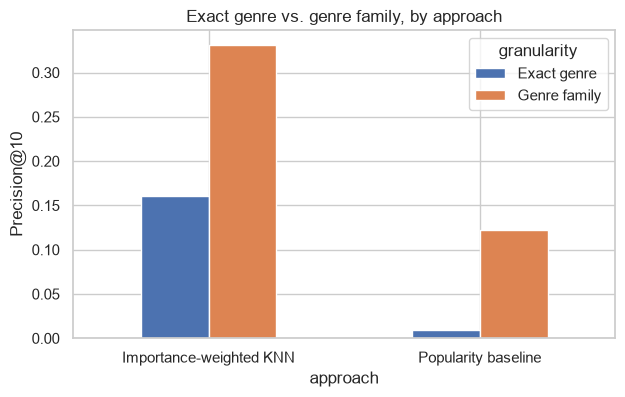

In [15]:
pivoted = granularity.pivot(index="approach", columns="granularity", values="precision_at_10")
pivoted.plot.bar(figsize=(7, 4))
plt.ylabel("Precision@10")
plt.xticks(rotation=0)
plt.title("Exact genre vs. genre family, by approach")
plt.show()

On this run, the popularity baseline jumped from 0.009 (exact genre) to
0.123 (genre family) — roughly **14x** — while importance-weighted KNN
only roughly doubled, from 0.161 to 0.331. My first reaction was that
this looked like it might undercut the earlier result — but working
through the ratios actually reassured me. With only 13 families instead
of 113 genres, landing in the right bucket gets easier for *any*
method, including one that completely ignores the query track. So the
recommender's real edge over the naive baseline is actually *larger* in
relative terms at the strict, exact-genre level (~18x) than at the
loosened, family level (~2.7x) — coarser bins flatter every method's
absolute score, including pure guessing, which is exactly why a bigger
number at the family level isn't the more honest one. What holds up
across both framings, and what I actually care about: the recommender
clearly and consistently beats the baseline either way, just by a
different margin depending on how strictly "correct" is defined.

## 9. Model interpretability with SHAP

I wanted to see *why* the genre classifier makes the calls it does, not
just accept the feature-importance weights as a black box — so I turned
to **SHAP** (SHapley Additive exPlanations), which attributes each
prediction to the individual features that pushed it in that direction.
This uses the same `shap.TreeExplainer` approach I'd use for any
tree-based model, applied here to a genuinely hard 114-class problem.

In [16]:
explanation, X_transformed = interpretability.compute_shap_values(classifier_pipeline, X_train, max_samples=500)

top_features = interpretability.top_shap_features(explanation, top_n=15)
top_features

,feature,mean_abs_shap
0,numeric__instrumentalness,0.002973
1,numeric__acousticness,0.002888
2,numeric__danceability,0.002068
3,numeric__duration_min,0.001747
4,numeric__energy,0.001625
5,numeric__loudness,0.001226
6,numeric__valence,0.001185
7,numeric__speechiness,0.001065
8,categorical__mood_quadrant_energetic_dark,0.000866
9,categorical__mood_quadrant_calm_dark,0.000646


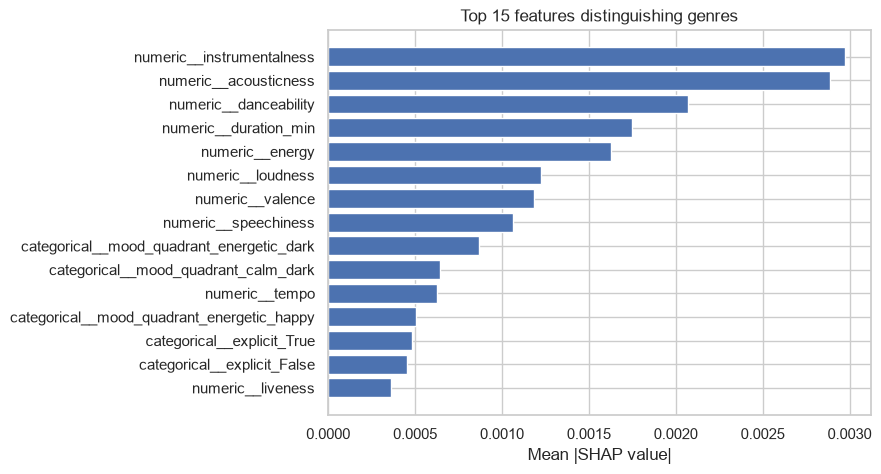

In [17]:
top_15 = interpretability.top_shap_features(explanation, top_n=15).sort_values("mean_abs_shap")

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top_15["feature"], top_15["mean_abs_shap"])
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Top 15 features distinguishing genres")
plt.show()

`instrumentalness` and `acousticness` come out on top, ahead of
`danceability` and `duration_min`. That lines up with how I'd
describe genres myself — "acoustic" vs. "electronic," "instrumental" vs.
"vocal-heavy" are some of the first things I'd listen for — which gave
me some confidence that the classifier (and by extension, the
importance-weighted distance metric it feeds in Section 6) is picking
up on musically real distinctions, not some quirk of the data.

## 10. Train and save the final recommender

In [18]:
final_recommender = model.train_recommender(tracks_df, use_weights=True)
model.save_pipeline(final_recommender)
print(f"Saved to {config.MODEL_PATH}")

Saved to /Users/nhamquochung/data/projects/recommendation_showcase/models/content_based_model.joblib


## 11. Sanity-check a real recommendation

In [19]:
sample_track_id = tracks_df.sample(1, random_state=1).index[0]
X_query, _ = data.split_features_target(tracks_df.loc[[sample_track_id]])
recs = final_recommender.recommend(X_query, k=5, exclude_own_id=True)

print("Seed:", tracks_df.loc[sample_track_id, "track_name"], "-", tracks_df.loc[sample_track_id, "artists"])
recs.merge(tracks_df[["track_name", "artists", config.GENRE_COL]], left_on="recommended_id", right_index=True)

Seed: Deep - Peter Sandberg


,query_id,recommended_id,rank,distance,track_name,artists,track_genre
0,7qt641kuazHzMIn4lbkns5,5dzKCZHfugPNGZn6VolIiE,1,1.658236,For Tammi,Gary Stadler,new-age
1,7qt641kuazHzMIn4lbkns5,4UirRyrZ431JmKmqVzfX8q,2,2.139698,"First Encounter - From ""Arrival"" Soundtrack",Jóhann Jóhannsson,ambient
2,7qt641kuazHzMIn4lbkns5,0oVB9LuiNmXn4hA8ShZU9B,3,2.139698,"First Encounter - From ""Arrival"" Soundtrack",Jóhann Jóhannsson,ambient
3,7qt641kuazHzMIn4lbkns5,7Fef812I3O0k9OHTOn1e2Y,4,2.243702,Infinite Calm,Dan Gibson's Solitudes,new-age
4,7qt641kuazHzMIn4lbkns5,5gG5Oqy8jKRp3HN4bjr24x,5,2.366242,Three Preludes: II. Allegro con Moto ‘Blue Lul...,George Gershwin;Nick Russoniello;The Golden Ag...,classical


A quiet ambient/new-age track pulling back other ambient and new-age
tracks, plus a classical piece, is exactly the kind of result that makes
me trust the precision@k numbers above rather than just take them on
faith — the recommendations look sensible by ear, not just by the
metric.

## What I actually took away from this

- Content-based recommendation needs no user data at all — that's a
  genuine advantage, not just a workaround, when there's no interaction
  history (or a brand-new item) to lean on
- Feature scaling matters a lot for distance-based methods, in a way it
  simply doesn't for tree-based ones
- Circular encoding (musical key) stops the model from lying to itself
  about which keys are "close"
- KNN works as a recommendation mechanism, and precision@k against a
  popularity baseline gave me a real way to check that, with no labels
  in the traditional sense
- A classifier's feature importances can usefully reweight a similarity
  metric — on this run, it beat two more "principled" alternatives
  (PCA, NCA), which was the opposite of what I expected going in
- SHAP made a hard 114-class problem legible enough to sanity-check
  against my own musical intuition

## Where I'd go next

- Run `python scripts/recommend.py "<a track name>"` to try the saved
  recommender from the command line.
- Run `streamlit run app/streamlit_app.py` to try it interactively.
- The head-to-head comparison against Part II's collaborative-filtering
  approach lives in `report/report.qmd` — worth reading if you want to
  see how the two techniques' tradeoffs actually stack up against each
  other.
